In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
from slinky_triplet_architectures import Triplet2DStiffnessMLP
Example = Triplet2DStiffnessMLP  # notebook alias


In [ ]:

validate_model(Example, der_K=jnp.array([2.0, 0.02]))

final_model, init_stiff_trace, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="data/output_old.npz", valid_file="data/output_valid_old.npz", n_epochs=500, lr=1e-2, init_K=jnp.array([2.0, 0.02]) )
# final_model, _k0, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)


Step 0    | LR: 1.000e-02  | Train: 1.83153e-04  | Valid: 1.46728e-04  | K: [2.00999965 0.02999997]
Step 10   | LR: 9.991e-03  | Train: 3.61318e-06  | Valid: 4.35908e-06  | K: [2.09279907 0.11666558]
Step 20   | LR: 9.965e-03  | Train: 1.02501e-05  | Valid: 9.91441e-06  | K: [2.11652939 0.13983342]
Step 30   | LR: 9.921e-03  | Train: 3.00674e-06  | Valid: 3.97494e-06  | K: [2.11007787 0.1280338 ]
Step 40   | LR: 9.859e-03  | Train: 2.98934e-06  | Valid: 4.62148e-06  | K: [2.10691835 0.12744457]
Step 50   | LR: 9.781e-03  | Train: 2.22223e-06  | Valid: 5.29197e-06  | K: [2.10565628 0.13276017]
Step 60   | LR: 9.685e-03  | Train: 1.58172e-06  | Valid: 7.58466e-06  | K: [2.0999832  0.13312285]
Step 70   | LR: 9.573e-03  | Train: 1.50524e-06  | Valid: 9.34589e-06  | K: [2.0956436  0.13535852]
Step 80   | LR: 9.446e-03  | Train: 1.48165e-06  | Valid: 9.09413e-06  | K: [2.09106952 0.13663229]
Step 90   | LR: 9.302e-03  | Train: 1.43152e-06  | Valid: 8.40051e-06  | K: [2.08591615 0.13704755]


NameError: name 'init_K' is not defined

In [4]:

print( "initial K: ", init_stiff_trace)
print( "learned K: ", final_model.K)


initial K:  [2.   0.02]
learned K:  [1.9685628  0.16364178]


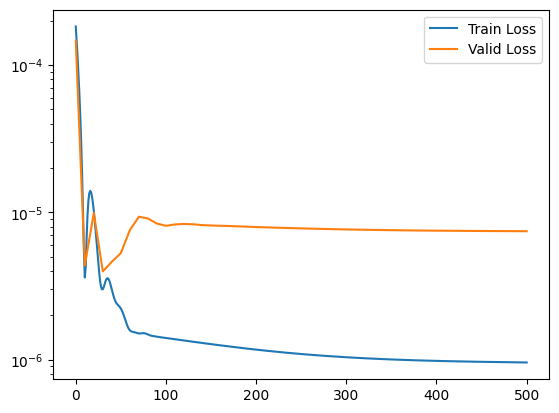

In [5]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()


In [7]:
from util import TestCase

train = TestCase.from_npz("data/output_old.npz")
valid = TestCase.from_npz("data/output_valid_old.npz")
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[0])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[ 0.    0.    0.    0.    0.   -0.1   0.    0.05]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[ 0.    0.    0.    0.    0.   -0.1   0.   -0.05]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [8]:

base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
animate(pred)


In [9]:
animate(valid.qs)


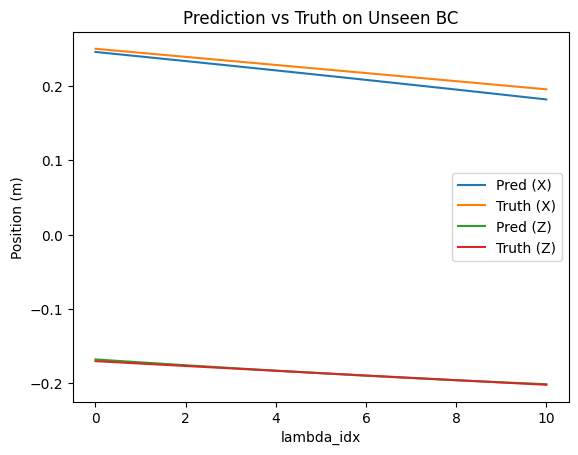

In [10]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
# plt.plot(pred[:, 5], label="Pred (Y)")
# plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.xlabel("lambda_idx")
plt.ylabel("Position (m)")
plt.show()


In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])


Training BC:
init:  [0.5 0.  0. ]
final:  [0.4  0.   0.05]
Validation BC:
init:  [0.5 0.  0. ]
final:  [ 0.4   0.   -0.05]


In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])


initial position of the middle node in the training data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the training data:  [ 2.04503756e-01 -5.49553991e-05 -1.51743630e-01]


In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])


initial position of the middle node in the validation data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the validation data:  [ 1.95521151e-01  6.64904575e-05 -2.01744441e-01]


In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])


initial position of the middle node in the prediction:  [ 2.45725384e-01 -3.95701415e-06 -1.67649213e-01]
final position of the middle node in the prediction:  [ 1.81884117e-01 -4.13896829e-05 -2.01003929e-01]
